In [1]:
import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# adjust this line to point towards root of the project directory.
# this file is inside /src, so using '..' to move 1 step up towards the root directory
os.chdir('..')
os.getcwd()

'/Users/rujalshrestha/Projects/mac-migration/gisc-412/nepal-wildfire'

In [3]:
wildfires = gpd.read_file('output/wildfires.gpkg')

In [4]:
wildfires['FRP'].describe()

count    79053.000000
mean        20.263197
std         35.206389
min          0.000000
25%          8.200000
50%         12.200000
75%         21.000000
max       2479.900000
Name: FRP, dtype: float64

/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


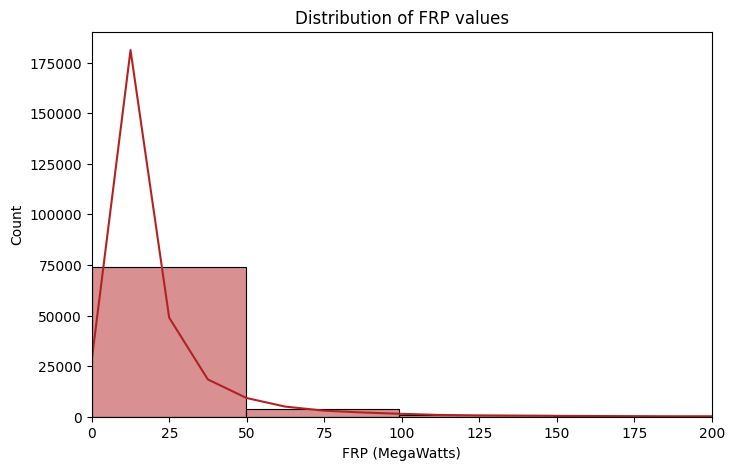

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(wildfires['FRP'], bins=50, kde=True, color='firebrick')
plt.xlim(0, 200)
plt.xlabel('FRP (MegaWatts)')
plt.ylabel('Count')
plt.title('Distribution of FRP values')
plt.show()

/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


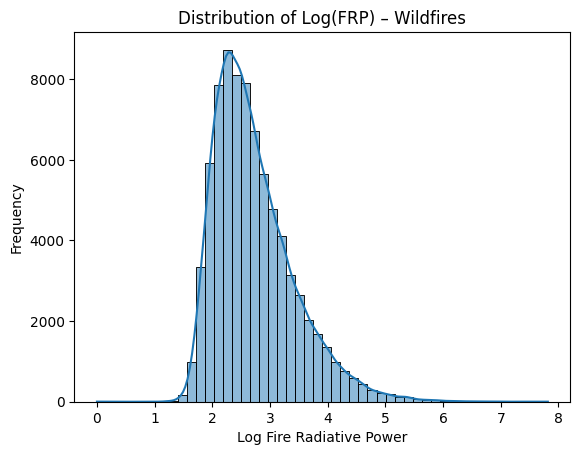

In [6]:
wildfires['log_FRP'] = np.log1p(wildfires['FRP'])

sns.histplot(wildfires['log_FRP'], bins=50, kde=True)
plt.title("Distribution of Log(FRP) – Wildfires")
plt.xlabel("Log Fire Radiative Power")
plt.ylabel("Frequency")
plt.show()

In [7]:
wildfires['log_FRP'].describe()

count    79053.000000
mean         2.724876
std          0.696782
min          0.000000
25%          2.219203
50%          2.580217
75%          3.091042
max          7.816377
Name: log_FRP, dtype: float64

In [8]:
def classify_frp(frp):
  if frp < 50:
    return 'low'
  elif frp < 200:
    return 'medium'
  else:
    return 'high'
  
wildfires['FRP_Class'] = wildfires['FRP'].apply(classify_frp)

wildfires.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,ACQ_DATE,ACQ_TIME,CONFIDENCE,BRIGHT_T31,FRP,datetime,index_right,...,PROVINCE_CODE,PROVINCE_NAME,DISTRICT_CODE,DISTRICT_NAME,STATE_NAME,LAYER_TYPE,SUBDIVISION_CODE,geometry,log_FRP,FRP_Class
0,27.5921,87.5385,306.2,2000-11-01,0500,55,292.1,6.2,2000-11-01 05:00:00,28.0,...,NPL.2_1,East,NPL.2.2_1,Mechi,Taplejung,District,NP.PW.TP,POINT (87.5385 27.5921),1.974081,low
1,29.1006,81.9170,330.6,2000-11-06,0518,87,293.7,43.0,2000-11-06 05:18:00,52.0,...,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Kalikot,District,NP.MP.KK,POINT (81.917 29.1006),3.784190,low
2,30.0881,81.3358,308.7,2000-11-07,0601,58,291.2,21.1,2000-11-07 06:01:00,50.0,...,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Humla,District,NP.MP.HU,POINT (81.3358 30.0881),3.095578,low
3,30.0841,81.3570,306.0,2000-11-07,0601,37,287.4,17.1,2000-11-07 06:01:00,50.0,...,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Humla,District,NP.MP.HU,POINT (81.357 30.0841),2.895912,low
4,30.1060,81.9647,315.0,2000-11-08,0506,64,282.6,41.6,2000-11-08 05:06:00,50.0,...,NPL.4_1,Mid-Western,NPL.4.2_1,Karnali,Humla,District,NP.MP.HU,POINT (81.9647 30.106),3.751854,low


In [9]:
wildfires['FRP_Class'].value_counts()

FRP_Class
low       73982
medium     4725
high        346
Name: count, dtype: int64

In [10]:
states = gpd.read_file('output/states.gpkg')

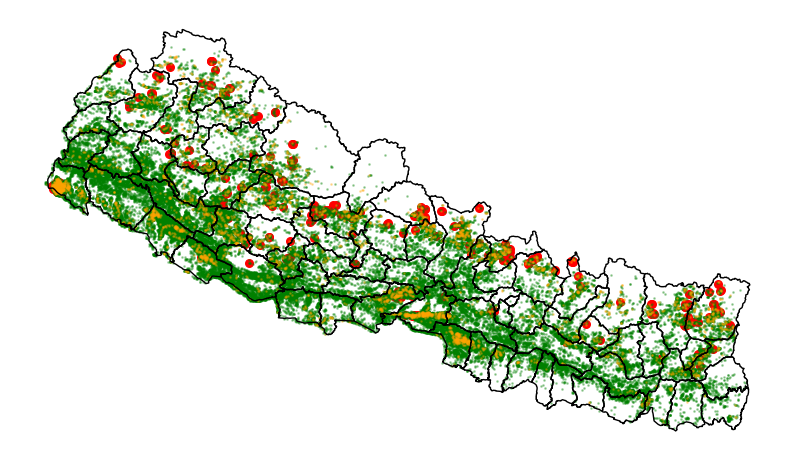

In [11]:
colors = {
  'low': 'green',
  'medium': 'orange',
  'high': 'red'
}

fig, ax = plt.subplots(figsize=(10,8))

states.boundary.plot(ax=ax, color='black', linewidth=1)

for cls, group in wildfires.groupby('FRP_Class'):
  group.plot(
    ax=ax,
    markersize=(30 if cls == 'high' else 1),
    color=colors[cls],
    label=cls,
    alpha=( 1 if cls == 'high' else 0.3)
  )

ax.set_axis_off()

plt.show()
